## Predicting Diabetic Diagnose.
    * Predicting the probabilty of a Diabettic Diagnose.
    * Implemented using XGBOOST
    * Categorical Values convertet to 1 and 0 using One Hot 
    * Training set split into Train and validation
    * Test Used for predicting real time predictions along with prability score
    
   

In [1]:
import numpy as np
import pandas as pd
import warnings
import datetime
import xgboost as xgb
import seaborn as sns
import itertools
import datetime
import sys
import os
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
%matplotlib inline
warnings.filterwarnings("ignore")




In [2]:
# Load the Training dataset for Bank Loan Dataset
MyData = pd.read_csv(r'..\..\data\kaggle_DiabeticDiagnosetrain.csv') 
MyData.shape


(700000, 26)

In [3]:
MyData.head(7)

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0
5,5,42,1,100,4.4,6.4,5.3,25.5,0.84,111,...,Female,White,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
6,6,41,2,148,3.4,5.6,3.7,27.9,0.89,130,...,Female,White,Graduate,Lower-Middle,Current,Employed,0,0,0,1.0


In [4]:
MyData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [5]:
MyData.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
MyData.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

In [7]:
MyData.head(5)

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [8]:
# Approach 3: One-hot encoding
dummy_columns = ["gender","ethnicity","education_level","income_level","smoking_status","employment_status"]
MyData_ohe = pd.get_dummies(MyData, columns=dummy_columns, dtype=int)
#X_test_ohe  = pd.get_dummies(X_test, columns=dummy_columns)
MyData_ohe.head(5)

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,smoking_status_Current,smoking_status_Former,smoking_status_Never,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,1,0,0,1,0,0,1,0,0,0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,0,0,1,0,0,1,1,0,0,0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,1,0,0,0,0,1,0,1,0,0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,1,0,0,1,0,0,1,0,0,0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,0,0,1,0,0,1,0,1,0,0


In [9]:
MyData_ohe.columns 

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes', 'gender_Female',
       'gender_Male', 'gender_Other', 'ethnicity_Asian', 'ethnicity_Black',
       'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White',
       'education_level_Graduate', 'education_level_Highschool',
       'education_level_No formal', 'education_level_Postgraduate',
       'income_level_High', 'income_level_Low', 'income_level_Lower-Middle',
       'income_level_Middle', 'income_level_Upper-Middle',
       'smoking_status_Current', 'smoking_status_Former',
       'smoking_status_Never', 'employment_status_Employed',
     

In [10]:
columns_rearranged = ['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'gender_Female',
       'gender_Male', 'gender_Other', 'ethnicity_Asian', 'ethnicity_Black',
       'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White',
       'education_level_Graduate', 'education_level_Highschool',
       'education_level_No formal', 'education_level_Postgraduate',
       'income_level_High', 'income_level_Low', 'income_level_Lower-Middle',
       'income_level_Middle', 'income_level_Upper-Middle',
       'smoking_status_Current', 'smoking_status_Former',
       'smoking_status_Never', 'employment_status_Employed',
       'employment_status_Retired', 'employment_status_Student',
       'employment_status_Unemployed', 'diagnosed_diabetes']  # Added parentheses around the tuple

MyData_ohe = MyData_ohe[columns_rearranged]
MyData_ohe.columns
##MyData_ohe.head(5)

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'gender_Female', 'gender_Male',
       'gender_Other', 'ethnicity_Asian', 'ethnicity_Black',
       'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White',
       'education_level_Graduate', 'education_level_Highschool',
       'education_level_No formal', 'education_level_Postgraduate',
       'income_level_High', 'income_level_Low', 'income_level_Lower-Middle',
       'income_level_Middle', 'income_level_Upper-Middle',
       'smoking_status_Current', 'smoking_status_Former',
       'smoking_status_Never', 'employment_status_Employed',
       'employment_status_R

In [11]:
columns_to_select = ['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 
       'gender_Female', 'gender_Male', 'gender_Other', 'ethnicity_Asian',
       'ethnicity_Black', 'ethnicity_Hispanic', 'ethnicity_Other',
       'ethnicity_White', 'education_level_Graduate',
       'education_level_Highschool', 'education_level_No formal',
       'education_level_Postgraduate', 'income_level_High', 'income_level_Low',
       'income_level_Lower-Middle', 'income_level_Middle',
       'income_level_Upper-Middle', 'smoking_status_Current',
       'smoking_status_Former', 'smoking_status_Never',
       'employment_status_Employed', 'employment_status_Retired',
       'employment_status_Student', 'employment_status_Unemployed']

X_train_ohe = MyData_ohe[columns_to_select]
y_train_ohe = MyData_ohe['diagnosed_diabetes']
X_train_ohe.head(5)

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,smoking_status_Current,smoking_status_Former,smoking_status_Never,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,1,0,0,1,0,0,1,0,0,0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,0,0,1,0,0,1,1,0,0,0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,1,0,0,0,0,1,0,1,0,0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,1,0,0,1,0,0,1,0,0,0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,0,0,1,0,0,1,0,1,0,0


In [12]:
y_train_ohe.head(5)

0    1.0
1    1.0
2    0.0
3    1.0
4    1.0
Name: diagnosed_diabetes, dtype: float64

In [13]:
# With random_state for reproducibility and shuffle=True (default)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_ohe, 
    y_train_ohe, 
    test_size=0.2, 
    random_state=42,  # For reproducibility
    shuffle=True       # Shuffle data before splitting (default is True)
)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print("Train:", len(X_train))  # Changed 'length' to 'len' which is the correct Python function to get length

(560000, 43) (560000,)
(140000, 43) (140000,)
Train: 560000


In [14]:
X_train.head(5)

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,smoking_status_Current,smoking_status_Former,smoking_status_Never,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed
363147,363147,52,3,51,2.9,6.1,6.3,28.8,0.90,117,...,1,0,0,0,0,1,1,0,0,0
29625,29625,34,3,38,6.9,7.4,6.0,30.3,0.91,103,...,0,0,1,0,0,1,1,0,0,0
9585,9585,54,2,138,7.5,8.3,5.1,23.1,0.79,102,...,0,1,0,0,0,1,1,0,0,0
608621,608621,62,2,31,5.3,6.7,10.7,32.2,0.91,107,...,0,0,0,0,1,0,1,0,0,0
667290,667290,49,1,75,3.9,6.6,5.1,27.7,0.88,116,...,0,1,0,0,0,1,0,1,0,0


In [15]:
independent_variables = ['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 
       'gender_Female', 'gender_Male', 'gender_Other', 'ethnicity_Asian',
       'ethnicity_Black', 'ethnicity_Hispanic', 'ethnicity_Other',
       'ethnicity_White', 'education_level_Graduate',
       'education_level_Highschool', 'education_level_No formal',
       'education_level_Postgraduate', 'income_level_High', 'income_level_Low',
       'income_level_Lower-Middle', 'income_level_Middle',
       'income_level_Upper-Middle', 'smoking_status_Current',
       'smoking_status_Former', 'smoking_status_Never',
       'employment_status_Employed', 'employment_status_Retired',
       'employment_status_Student', 'employment_status_Unemployed']
X_train_fit = X_train[independent_variables]
X_val_fit   = X_val[independent_variables]
X_train_fit.head(5)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,smoking_status_Current,smoking_status_Former,smoking_status_Never,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed
363147,52,3,51,2.9,6.1,6.3,28.8,0.90,117,77,...,1,0,0,0,0,1,1,0,0,0
29625,34,3,38,6.9,7.4,6.0,30.3,0.91,103,82,...,0,0,1,0,0,1,1,0,0,0
9585,54,2,138,7.5,8.3,5.1,23.1,0.79,102,70,...,0,1,0,0,0,1,1,0,0,0
608621,62,2,31,5.3,6.7,10.7,32.2,0.91,107,74,...,0,0,0,0,1,0,1,0,0,0
667290,49,1,75,3.9,6.6,5.1,27.7,0.88,116,82,...,0,1,0,0,0,1,0,1,0,0


In [16]:
X_val_fit.head(5)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,smoking_status_Current,smoking_status_Former,smoking_status_Never,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed
637949,60,2,144,4.3,7.3,5.5,23.1,0.83,100,68,...,1,0,0,0,0,1,1,0,0,0
656465,50,2,48,4.7,7.2,9.1,26.6,0.92,120,79,...,0,1,0,1,0,0,1,0,0,0
337739,34,1,123,3.4,7.0,7.1,24.1,0.88,107,84,...,1,0,0,0,0,1,1,0,0,0
230222,52,2,26,6.1,7.3,5.0,22.9,0.83,119,82,...,0,1,0,1,0,0,1,0,0,0
82039,39,3,70,4.9,8.8,7.8,29.3,0.84,116,82,...,0,1,0,0,0,1,1,0,0,0


In [17]:
# Launch a classifier
# XGBoost Training Parameter Reference: 
#   https://xgboost.readthedocs.io/en/latest/parameter.html
classifier = xgb.XGBClassifier(objective="binary:logistic",
                               eval_metric=['logloss'],
                               enable_categorical=True,
                               early_stopping_rounds=10)

In [18]:
classifier

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=True, eval_metric=['logloss'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [19]:
classifier.fit(X_train_fit,
               y_train, 
               eval_set = [(X_train_fit, y_train), (X_val_fit, y_val)])

[0]	validation_0-logloss:0.63597	validation_1-logloss:0.63574
[1]	validation_0-logloss:0.62168	validation_1-logloss:0.62169
[2]	validation_0-logloss:0.61338	validation_1-logloss:0.61356
[3]	validation_0-logloss:0.60813	validation_1-logloss:0.60865
[4]	validation_0-logloss:0.60401	validation_1-logloss:0.60481
[5]	validation_0-logloss:0.60167	validation_1-logloss:0.60265
[6]	validation_0-logloss:0.59987	validation_1-logloss:0.60109
[7]	validation_0-logloss:0.59850	validation_1-logloss:0.59992
[8]	validation_0-logloss:0.59688	validation_1-logloss:0.59847
[9]	validation_0-logloss:0.59570	validation_1-logloss:0.59759
[10]	validation_0-logloss:0.59493	validation_1-logloss:0.59708
[11]	validation_0-logloss:0.59412	validation_1-logloss:0.59649
[12]	validation_0-logloss:0.59361	validation_1-logloss:0.59616
[13]	validation_0-logloss:0.59286	validation_1-logloss:0.59567
[14]	validation_0-logloss:0.59245	validation_1-logloss:0.59550
[15]	validation_0-logloss:0.59172	validation_1-logloss:0.59498
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=True, eval_metric=['logloss'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [20]:
eval_result = classifier.evals_result()

In [21]:
training_rounds = range(len(eval_result['validation_0']['logloss']))

In [22]:
print(training_rounds)

range(0, 78)


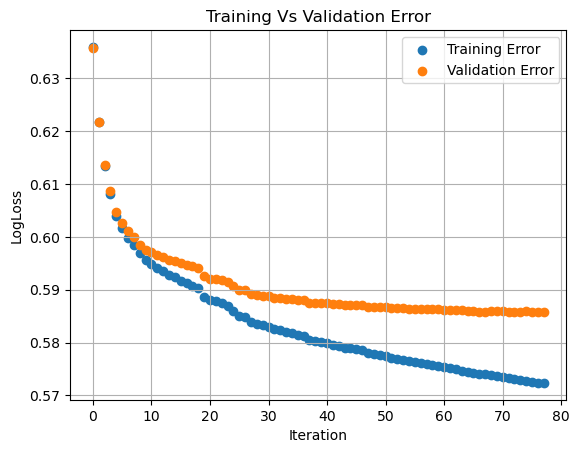

In [23]:
plt.scatter(x=training_rounds,y=eval_result['validation_0']['logloss'],label='Training Error')
plt.scatter(x=training_rounds,y=eval_result['validation_1']['logloss'],label='Validation Error')
plt.grid(True)
plt.xlabel('Iteration')
plt.ylabel('LogLoss')
plt.title('Training Vs Validation Error')
plt.legend()
plt.show()

In [24]:
y_pred = classifier.predict(X_val_fit)

Accuracy: 0.6811
Accuracy: 68.11%
Accuracy (from confusion matrix): 0.6811
Accuracy (from confusion matrix): 68.11%


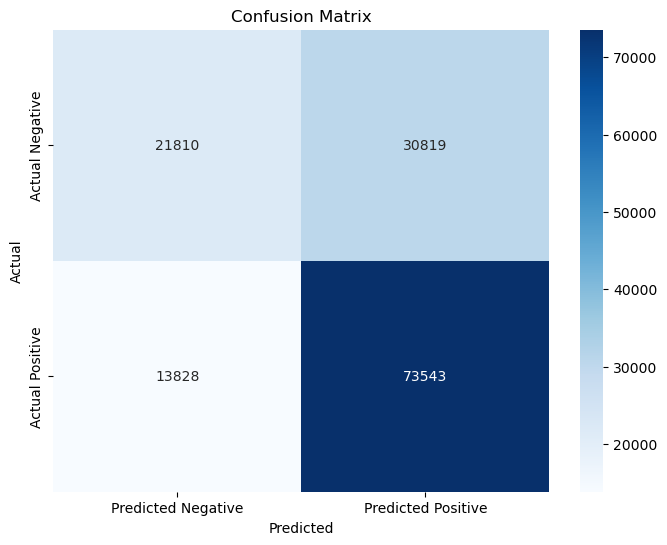

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

# Get confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Calculate accuracy manually from confusion matrix
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    accuracy_from_cm = (tp + tn) / (tp + tn + fp + fn)
    print(f"Accuracy (from confusion matrix): {accuracy_from_cm:.4f}")
    print(f"Accuracy (from confusion matrix): {accuracy_from_cm*100:.2f}%")

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# For multi-class problems, you might want to normalize the confusion matrix
if cm.shape[0] > 2:
    # Normalize the confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot normalized confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Normalized Confusion Matrix')
    plt.show()

In [26]:
# Calculate accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

# Alternative method using confusion matrix
from sklearn.metrics import confusion_matrix

# Get confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Calculate accuracy manually from confusion matrix
# For binary classification:
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    accuracy_from_cm = (tp + tn) / (tp + tn + fp + fn)
    print(f"Accuracy (from confusion matrix): {accuracy_from_cm:.4f}")
    print(f"Accuracy (from confusion matrix): {accuracy_from_cm*100:.2f}%")

Accuracy: 0.6811
Accuracy: 68.11%
Accuracy (from confusion matrix): 0.6811
Accuracy (from confusion matrix): 68.11%


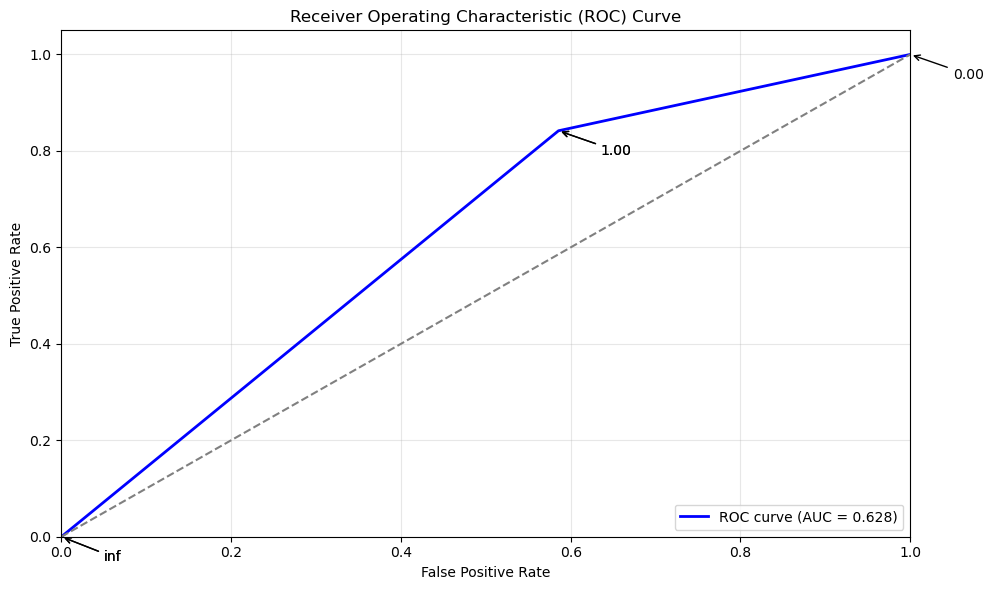

AUC: 0.6281


In [27]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get predicted probabilities for the positive class
# For binary classification, we need the probability of the positive class (class 1)
# y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

# Calculate AUC
roc_auc = auc(fpr, tpr)
# Alternative: roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Add some threshold annotations
# Select a few thresholds to annotate
threshold_indices = np.linspace(0, len(thresholds) - 1, 5, dtype=int)
for i in threshold_indices:
    plt.annotate(f'{thresholds[i]:.2f}', 
                 xy=(fpr[i], tpr[i]), 
                 xytext=(fpr[i]+0.05, tpr[i]-0.05),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3'))

plt.tight_layout()
plt.show()

# Print AUC value
print(f"AUC: {roc_auc:.4f}")

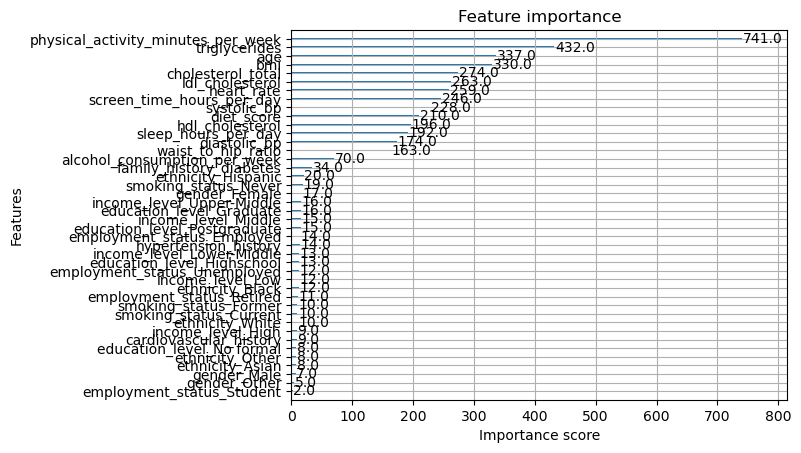

In [28]:
xgb.plot_importance(classifier)
plt.show()

In [29]:
# Get feature importance as a dictionary
feature_importance = classifier.get_booster().get_score(importance_type='weight')

# Convert to a more readable format (sorted by importance)
import pandas as pd

# Create a DataFrame for better display
importance_df = pd.DataFrame({
    'Feature': list(feature_importance.keys()),
    'Importance': list(feature_importance.values())
})

# Sort by importance in descending order
importance_df = importance_df.sort_values('Importance', ascending=False)

# Display the feature importance
print(importance_df)

                               Feature  Importance
2   physical_activity_minutes_per_week       741.0
14                       triglycerides       432.0
0                                  age       337.0
6                                  bmi       330.0
11                   cholesterol_total       274.0
13                     ldl_cholesterol       263.0
10                          heart_rate       259.0
5            screen_time_hours_per_day       246.0
8                          systolic_bp       228.0
3                           diet_score       210.0
12                     hdl_cholesterol       196.0
4                  sleep_hours_per_day       192.0
9                         diastolic_bp       174.0
7                   waist_to_hip_ratio       163.0
1         alcohol_consumption_per_week        70.0
15             family_history_diabetes        34.0
23                  ethnicity_Hispanic        20.0
37                smoking_status_Never        19.0
18                       gender

In [30]:
probabilities = classifier.predict_proba(X_val_fit)

In [31]:
val_probabilities_df = pd.DataFrame({
    'id': X_val['id'].reset_index(drop=True),
    # Extract the probability for class 1 (second column)
    'y': pd.Series(probabilities[:, 1]).reset_index(drop=True)  # Using column index 1 for positive class probability
    # Alternatively, if you want both probabilities:
    # 'y_class0': pd.Series(probabilities[:, 0]).reset_index(drop=True),
    # 'y_class1': pd.Series(probabilities[:, 1]).reset_index(drop=True)
})
val_probabilities_df.head(10)

,id,y
0,637949,0.392066
1,656465,0.572982
2,337739,0.497506
3,230222,0.774383
4,82039,0.623783
5,333655,0.677258
6,668993,0.400440
7,394818,0.667894
8,54454,0.623411
9,211991,0.473892


In [32]:
# Load the test dataset for Bank Dataset
MyData_test = pd.read_csv(r'..\..\data\kaggle_DiabeticDiagnosetest.csv') 
MyData_test.shape

(300000, 25)

In [33]:
MyData_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 25 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  300000 non-null  int64  
 1   age                                 300000 non-null  int64  
 2   alcohol_consumption_per_week        300000 non-null  int64  
 3   physical_activity_minutes_per_week  300000 non-null  int64  
 4   diet_score                          300000 non-null  float64
 5   sleep_hours_per_day                 300000 non-null  float64
 6   screen_time_hours_per_day           300000 non-null  float64
 7   bmi                                 300000 non-null  float64
 8   waist_to_hip_ratio                  300000 non-null  float64
 9   systolic_bp                         300000 non-null  int64  
 10  diastolic_bp                        300000 non-null  int64  
 11  heart_rate                

In [34]:
MyData_test.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,849999.500000,50.432397,2.089693,92.349087,5.945838,6.997795,6.011278,25.881906,0.859007,116.374117,75.396013,70.048350,187.308620,53.813557,103.416083,123.538480,0.152920,0.184410,0.033110
std,86602.684716,11.938741,1.066214,62.187399,1.481068,0.914693,2.060472,2.894289,0.038523,11.252146,6.950340,7.090543,18.413053,8.398126,20.571855,28.965441,0.359911,0.387819,0.178924
min,700000.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.690000,91.000000,51.000000,42.000000,107.000000,22.000000,51.000000,31.000000,0.000000,0.000000,0.000000
25%,774999.750000,42.000000,1.000000,51.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,174.000000,48.000000,89.000000,104.000000,0.000000,0.000000,0.000000
50%,849999.500000,50.000000,2.000000,77.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000
75%,924999.250000,59.000000,3.000000,115.000000,7.000000,7.600000,7.400000,27.800000,0.890000,124.000000,80.000000,75.000000,200.000000,60.000000,117.000000,142.000000,0.000000,0.000000,0.000000
max,999999.000000,89.000000,9.000000,748.000000,9.900000,9.900000,15.900000,38.300000,1.050000,170.000000,104.000000,101.000000,285.000000,91.000000,226.000000,290.000000,1.000000,1.000000,1.000000


In [35]:
MyData_test.columns


Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history'],
      dtype='object')

In [36]:
# Approach 3: One-hot encoding
dummy_columns = ["gender","ethnicity","education_level","income_level","smoking_status","employment_status"]
MyData_test_ohe = pd.get_dummies(MyData_test, columns=dummy_columns, dtype=int)
#X_test_ohe  = pd.get_dummies(X_test, columns=dummy_columns)
MyData_test_ohe.head(5)


,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,smoking_status_Current,smoking_status_Former,smoking_status_Never,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,700000,45,4,100,4.3,6.8,6.2,25.5,0.84,123,...,0,1,0,0,1,0,1,0,0,0
1,700001,35,1,87,3.5,4.6,9.0,28.6,0.88,120,...,0,1,0,0,0,1,0,0,0,1
2,700002,45,1,61,7.6,6.8,7.0,28.5,0.94,112,...,0,0,0,0,0,1,1,0,0,0
3,700003,55,2,81,7.3,7.3,5.0,26.9,0.91,114,...,0,1,0,0,1,0,1,0,0,0
4,700004,77,2,29,7.3,7.6,8.5,22.0,0.83,131,...,0,0,0,1,0,0,0,0,0,1


In [37]:
MyData_test_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 43 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  300000 non-null  int64  
 1   age                                 300000 non-null  int64  
 2   alcohol_consumption_per_week        300000 non-null  int64  
 3   physical_activity_minutes_per_week  300000 non-null  int64  
 4   diet_score                          300000 non-null  float64
 5   sleep_hours_per_day                 300000 non-null  float64
 6   screen_time_hours_per_day           300000 non-null  float64
 7   bmi                                 300000 non-null  float64
 8   waist_to_hip_ratio                  300000 non-null  float64
 9   systolic_bp                         300000 non-null  int64  
 10  diastolic_bp                        300000 non-null  int64  
 11  heart_rate                

In [38]:
MyData_test_ohe.head(5)

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,smoking_status_Current,smoking_status_Former,smoking_status_Never,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,700000,45,4,100,4.3,6.8,6.2,25.5,0.84,123,...,0,1,0,0,1,0,1,0,0,0
1,700001,35,1,87,3.5,4.6,9.0,28.6,0.88,120,...,0,1,0,0,0,1,0,0,0,1
2,700002,45,1,61,7.6,6.8,7.0,28.5,0.94,112,...,0,0,0,0,0,1,1,0,0,0
3,700003,55,2,81,7.3,7.3,5.0,26.9,0.91,114,...,0,1,0,0,1,0,1,0,0,0
4,700004,77,2,29,7.3,7.6,8.5,22.0,0.83,131,...,0,0,0,1,0,0,0,0,0,1


In [39]:
X_test_ohe_fit = MyData_test_ohe[independent_variables]
X_test_ohe_fit.head(5)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,smoking_status_Current,smoking_status_Former,smoking_status_Never,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,45,4,100,4.3,6.8,6.2,25.5,0.84,123,70,...,0,1,0,0,1,0,1,0,0,0
1,35,1,87,3.5,4.6,9.0,28.6,0.88,120,74,...,0,1,0,0,0,1,0,0,0,1
2,45,1,61,7.6,6.8,7.0,28.5,0.94,112,71,...,0,0,0,0,0,1,1,0,0,0
3,55,2,81,7.3,7.3,5.0,26.9,0.91,114,81,...,0,1,0,0,1,0,1,0,0,0
4,77,2,29,7.3,7.6,8.5,22.0,0.83,131,78,...,0,0,0,1,0,0,0,0,0,1


In [40]:
y_pred_test = classifier.predict(X_test_ohe_fit)

In [41]:
submission_df = pd.DataFrame({
    'id': MyData_test_ohe['id'].reset_index(drop=True),
    'y': pd.Series(y_pred_test).reset_index(drop=True)
})

In [42]:
submission_df.head(5)

,id,y
0,700000,1
1,700001,1
2,700002,1
3,700003,0
4,700004,1


In [43]:
# Count distinct values in column Y
distinct_count = submission_df['y'].value_counts()
print(distinct_count)

# If you just want the number of distinct values
num_distinct = submission_df['y'].nunique()
print(f"Number of distinct values: {num_distinct}")

y
1    207420
0     92580
Name: count, dtype: int64
Number of distinct values: 2


In [44]:
test_probabilities = classifier.predict_proba(X_test_ohe_fit)


In [45]:
submission_probabilities_df = pd.DataFrame({
    'id': MyData_test_ohe['id'].reset_index(drop=True),
    # Extract the probability for class 1 (second column)
    'diagnosed_diabetes': pd.Series(test_probabilities[:, 1]).reset_index(drop=True)  # Using column index 1 for positive class probability
    # Alternatively, if you want both probabilities:
    # 'y_class0': pd.Series(probabilities[:, 0]).reset_index(drop=True),
    # 'y_class1': pd.Series(probabilities[:, 1]).reset_index(drop=True)
})
submission_probabilities_df.head(10)

,id,diagnosed_diabetes
0,700000,0.535073
1,700001,0.666693
2,700002,0.751671
3,700003,0.374416
4,700004,0.932065
5,700005,0.669774
6,700006,0.720307
7,700007,0.934549
8,700008,0.582137
9,700009,0.843976


In [46]:
MyData_test_ohe.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,smoking_status_Current,smoking_status_Former,smoking_status_Never,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,...,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,849999.500000,50.432397,2.089693,92.349087,5.945838,6.997795,6.011278,25.881906,0.859007,116.374117,...,0.254283,0.414163,0.182080,0.146320,0.148127,0.705553,0.726643,0.170690,0.029730,0.072937
std,86602.684716,11.938741,1.066214,62.187399,1.481068,0.914693,2.060472,2.894289,0.038523,11.252146,...,0.435458,0.492578,0.385911,0.353427,0.355226,0.455794,0.445683,0.376238,0.169842,0.260033
min,700000.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.690000,91.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,774999.750000,42.000000,1.000000,51.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,849999.500000,50.000000,2.000000,77.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,924999.250000,59.000000,3.000000,115.000000,7.000000,7.600000,7.400000,27.800000,0.890000,124.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,999999.000000,89.000000,9.000000,748.000000,9.900000,9.900000,15.900000,38.300000,1.050000,170.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [47]:
submission_probabilities_df.describe()

,id,diagnosed_diabetes
count,300000.000000,300000.000000
mean,849999.500000,0.601679
std,86602.684716,0.192792
min,700000.000000,0.031085
25%,774999.750000,0.462552
50%,849999.500000,0.606815
75%,924999.250000,0.747594
max,999999.000000,0.994993


In [48]:
submission_probabilities_df.shape

(300000, 2)

In [49]:
submission_probabilities_df.to_csv(r'..\..\results\submission.csv', index=False)
print("CSV file has been created successfully!")

CSV file has been created successfully!


In [50]:
# Define the threshold as a variable
threshold = 0.5

# Filter the DataFrame to show only rows where y >= threshold
filtered_df = submission_probabilities_df[submission_probabilities_df['diagnosed_diabetes'] >= threshold]

# Display all filtered rows
print(f"Rows where diagnosed_diabetes >= {threshold}:")
display(filtered_df)

# Count the total number of rows where y >= threshold
count = len(filtered_df)
print(f"\nTotal number of rows where diagnosed_diabetes >= {threshold}: {count}")

# Optional: Calculate the percentage of rows that meet the condition
percentage = (count / len(submission_probabilities_df)) * 100
print(f"Percentage of rows where diagnosed_diabetes >= {threshold}: {percentage:.2f}%")

Rows where diagnosed_diabetes >= 0.5:


,id,diagnosed_diabetes
0,700000,0.535073
1,700001,0.666693
2,700002,0.751671
4,700004,0.932065
5,700005,0.669774
...,...,...
299995,999995,0.740507
299996,999996,0.550840
299997,999997,0.666754
299998,999998,0.596491



Total number of rows where diagnosed_diabetes >= 0.5: 207420
Percentage of rows where diagnosed_diabetes >= 0.5: 69.14%
